## Configuration 

In [1]:
# Configuration de récupération 
URI_API_BASE_MONGO_DB_LOCAL = "http://localhost:8080"
URI_API_BASE_MONGO_DB_AZURE = "https://api-base-fastapi-mpt-dkhjb0cydga2aydc.canadacentral-01.azurewebsites.net"
URI_API_REQUEST_GITHUB = "http://localhost:7000"


## Vérification du nombre d'éléments en base

In [2]:
import requests

def appel_api_base_count_collection( url = URI_API_BASE_MONGO_DB_LOCAL):
    url = url+"/count"
    response = requests.get(url)
    print(f"code http: "+str(response.status_code))
    print(f"count : "+str(response.text))

appel_api_base_count_collection()

code http: 200
count : 87475


## Appel à l'API Rest github

In [3]:
import requests

def get_call(paths,url, params=None, header=None):
    url = f"{url}/{paths}"
    response = requests.get(url, params=params, headers=header)
    if response.status_code == 200:
        return response.json()
    else:
        print(f"Error: {response.status_code} - {response.json().get('message', 'Unknown error')}")
        return None
    
repositories=get_call(paths="start",url=URI_API_REQUEST_GITHUB)
print(repositories)

{}


## Vérification de l'insertion des données

In [4]:
import requests

def appel_api_base_count_collection( url = URI_API_BASE_MONGO_DB_LOCAL):
    url = url+"/count"
    response = requests.get(url)
    print(f"code http: "+str(response.status_code))
    print(f"count : "+str(response.text))

appel_api_base_count_collection()

code http: 200
count : 87475


## Ajout de donnée dans la base de donnée MONGO

In [20]:
import pandas as pd
def has_valid_owner(owner):
    required_fields = ['login', 'id', 'html_url']
    return all(field in owner for field in required_fields)
data = pd.read_pickle("repositories_data.pkl")
data = data.dropna(subset=['owner'])  
data = data[data['owner'].apply(has_valid_owner)] 
data = data.to_dict(orient="records")


In [7]:
def appel_api_add_data(url =URI_API_BASE_MONGO_DB_LOCAL, body= data):
    url = url+ "/add_data"
    response = requests.post(url,json=body)
    return response.json()
appel_api_add_data()

KeyboardInterrupt: 

## Visualisation d'une donnée type

In [5]:
import requests

def appel_api_base_show_data(url = URI_API_BASE_MONGO_DB_LOCAL,page = 1,page_size = 10000):
    url = url+"/show_data?page="+str(page)+"&page_size="+str(page_size)
    response = requests.get(url)
    print(f"code http: "+str(response.status_code))
    return (response.json())

# Appel de l'API avec les bonnes dates
reponse = appel_api_base_show_data( url=URI_API_BASE_MONGO_DB_LOCAL)
reponse

code http: 200


{'page': 1,
 'page_size': 10000,
 'total_pages': 9,
 'total_documents': 87475,
 'data': [{'id': 739794260,
   'node_id': 'R_kgDOLBhdVA',
   'name': 'astro-boilerplate',
   'full_name': 'Tailus-UI/astro-boilerplate',
   'private': False,
   'owner': {'login': 'Tailus-UI',
    'id': 94113125,
    'html_url': 'https://github.com/Tailus-UI'},
   'html_url': 'https://github.com/Tailus-UI/astro-boilerplate',
   'description': 'Astro starter project with Tailwindcss and Tailus Themer installed and configured.',
   'fork': False,
   'created_at': '2024-01-06T15:09:48',
   'updated_at': '2025-01-05T10:00:14',
   'pushed_at': '2024-01-06T15:13:39',
   'language': 'Astro',
   'forks_count': 2,
   'stargazers_count': 12,
   'watchers_count': 12,
   'open_issues_count': 0},
  {'id': 739594557,
   'node_id': 'R_kgDOLBVRPQ',
   'name': 'streampark-piflowx',
   'full_name': 'mayi295940/streampark-piflowx',
   'private': False,
   'owner': {'login': 'mayi295940',
    'id': 16362611,
    'html_url': 'ht

## Entrainement du modèle à partir des données récupérées précédemment 

### Pré-traitement des données récupérées

In [6]:
import pandas as pd

df_new = pd.DataFrame(reponse['data'])

df_new = df_new[['name','full_name','description','stargazers_count','watchers_count','forks_count','created_at','updated_at','language']]
df_new = df_new.dropna(subset=['created_at', 'language'])
df_new['created_at'] = df_new['created_at'].astype(str)
df_new['created_at'] = df_new['created_at'].apply(lambda x: x + "Z" if not x.endswith("Z") else x)
df_new['created_at'] = pd.to_datetime(df_new['created_at'])
max_date = df_new['created_at'].max()  # La date la plus récente
recent_month = max_date.month
recent_year = max_date.year  

# Filtrer le DataFrame pour ne garder que les données du mois le plus récent
df_recent = df_new[df_new['created_at'].dt.month == recent_month]
df_recent = df_recent[df_recent['created_at'].dt.year == recent_year]
df_recent['created_at'] = df_recent['created_at'].astype(str)

df_recent


,name,full_name,description,stargazers_count,watchers_count,forks_count,created_at,updated_at,language
0,astro-boilerplate,Tailus-UI/astro-boilerplate,Astro starter project with Tailwindcss and Tai...,12,12,2,2024-01-06 15:09:48+00:00,2025-01-05T10:00:14,Astro
1,streampark-piflowx,mayi295940/streampark-piflowx,None,12,12,4,2024-01-06 00:31:22+00:00,2025-01-11T14:09:56,Scala
2,Data-Engineering-Pipeline,gurezende/Data-Engineering-Pipeline,Creating a Data Pipeline for Stock Data,12,12,1,2024-01-06 23:06:41+00:00,2024-12-04T11:05:50,Jupyter Notebook
3,Plug,lyricalsoul/Plug,Plugin management library for Swift.,12,12,0,2024-01-06 05:23:05+00:00,2024-08-28T15:54:47,Swift
4,RWKV5-LM-LoRA,OpenMOSE/RWKV5-LM-LoRA,"RWKV v5,v6 LoRA Trainer on Cuda and Rocm Platf...",12,12,4,2024-01-06 05:33:55+00:00,2025-01-01T16:44:41,Python
...,...,...,...,...,...,...,...,...,...
9994,firewall-bypass,redeflesq/firewall-bypass,Download data from the internet bypassing the ...,36,36,6,2024-01-20 14:38:44+00:00,2024-10-03T05:17:53,C
9995,100-Days-of-GPTs,BlueBirdBack/100-Days-of-GPTs,A hundred GPTs stand ready. They teach. They s...,35,35,1,2024-01-20 07:34:34+00:00,2025-02-08T09:51:56,Jupyter Notebook
9996,expenses_tracker,romain-girou/expenses_tracker,None,35,35,28,2024-01-20 09:58:08+00:00,2025-02-08T09:51:44,Dart
9998,OVFormer,fanghaook/OVFormer,[ECCV 2024] Unified Embedding Alignment for Op...,34,34,1,2024-01-20 11:38:18+00:00,2025-01-06T07:25:32,Python


In [7]:
try:
    df_old = pd.read_pickle("historique.pkl")
except FileNotFoundError:
    df_old = pd.DataFrame() 
df = pd.concat([df_old, df_new]).drop_duplicates(subset=['created_at'])
df.to_pickle("historique.pkl")
#Enlever tous les langages qui ne contiennent qu'un dépôt github
language_counts = df['language'].value_counts()
df['language'].value_counts()
df = df[df['language'].isin(language_counts[language_counts > 1].index)]
df['created_at'] = df['created_at'].astype(str)

### Affichage de la distibution des données par langage

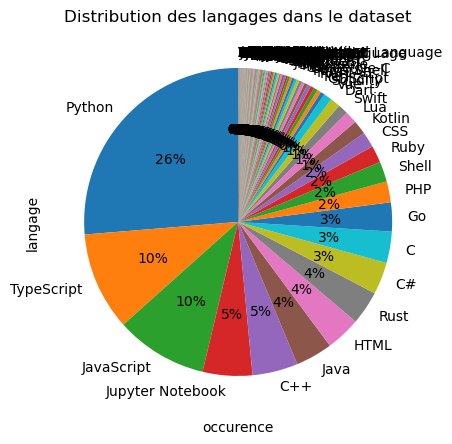

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
# sns.countplot(y=df["language"], order=df["language"].value_counts().index)
plt.pie(df['language'].value_counts(), labels=df['language'].value_counts().index, startangle= 90, autopct= '%.f%%')
plt.xlabel('occurence')
plt.ylabel('langage')
plt.title("Distribution des langages dans le dataset")
plt.show()

### Entrainement du modele

In [9]:
# Différents modèles proposés
MODELE_NAME = "gradient_boosting"
# MODELE_NAME = "random_forest"


In [10]:

import requests


url = "http://localhost:8085/train"


# Je prend que les 100 premiers données pour accélérer l'apprentissage
data = {
    "model_name": MODELE_NAME,
    "epochs": 10,
    "batch_size": 32,
    "metrics": {"lr": 0.01, "n_estimators": 100},
    "data": df.head(100).to_dict(orient='records') 
}


response = requests.post(url, json=data)


print(response.status_code)
model_name, model_version, acc = response.json()
print(f"Modèle {model_name} Version : {model_version} enregistré Modèle entraîné avec une accuracy de {acc}")

200
Modèle gradient_boosting Version : 2 enregistré Modèle entraîné avec une accuracy de 0.0


## Mettre en production la version du modèle 

In [11]:
import requests

URI_CHANGE_STAGING_MODEL= "localhost:8085"

def appel_api_model_change_staging( url = URI_CHANGE_STAGING_MODEL, path="/model-stage", model_name = model_name,version = model_version,stage = "Production"):
    url = f"http://{url}{path}?model_name={model_name}&version={version}&stage={stage}"
    response = requests.post(url)
    print(f"code http: "+str(response.status_code))
    print(f"count : "+str(response.text))

appel_api_model_change_staging()


code http: 200
count : {"message":"Modèle gradient_boosting version 2 en staging Production."}


## Prédiction suite à l'entrainement

In [12]:

import requests


url = "http://localhost:8084/predict"

#les données sont les dépôts github du mois le plus récent des données obtenus
data = {
    "model_name": model_name,
    "model_version": str(model_version),
    "data": df_recent.to_dict(orient = 'records')
}


response = requests.post(url, json=data)

print(response.status_code)
print(response.json())

200
{'top 5 des langages qui croissent le plus': [{'langage': 'CSS', 'probabilité': 123.76877970134456}, {'langage': 'Astro', 'probabilité': 101.35902190274223}, {'langage': 'HCL', 'probabilité': 77.80195632338314}, {'langage': 'Rust', 'probabilité': 77.13181444824451}, {'langage': 'R', 'probabilité': 65.99363120206814}]}
